In [533]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

path = "../Data/paddydataset.csv"
df = pd.read_csv(path)
df.head()

,Hectares,Agriblock,Variety,Soil Types,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery,Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,...,Wind Direction_D1_D30,Wind Direction_D31_D60,Wind Direction_D61_D90,Wind Direction_D91_D120,Relative Humidity_D1_D30,Relative Humidity_D31_D60,Relative Humidity_D61_D90,Relative Humidity_D91_D120,Trash(in bundles),Paddy yield(in Kg)
0,6,Cuddalore,CO_43,alluvial,150,75.0,dry,120,6,240,...,SW,W,NNW,WSW,72.0,78,88,85,540,35028
1,6,Kurinjipadi,ponmani,clay,150,75.0,wet,120,6,240,...,NW,S,SE,SSE,64.6,85,84,87,600,35412
2,6,Panruti,delux ponni,alluvial,150,75.0,dry,120,6,240,...,ENE,NE,NNE,W,85.0,96,84,79,600,36300
3,6,Kallakurichi,CO_43,clay,150,75.0,wet,120,6,240,...,W,WNW,SE,S,88.5,95,81,84,540,35016
4,6,Sankarapuram,ponmani,alluvial,150,75.0,dry,120,6,240,...,SSE,W,SW,NW,72.7,91,83,81,600,34044


### ========================== EDA ====================================

In [534]:
# Check for missing value, duplicates, and data dtype
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2789 entries, 0 to 2788
Data columns (total 45 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Hectares                            2789 non-null   int64  
 1   Agriblock                           2789 non-null   str    
 2   Variety                             2789 non-null   str    
 3   Soil Types                          2789 non-null   str    
 4   Seedrate(in Kg)                     2789 non-null   int64  
 5   LP_Mainfield(in Tonnes)             2789 non-null   float64
 6   Nursery                             2789 non-null   str    
 7   Nursery area (Cents)                2789 non-null   int64  
 8   LP_nurseryarea(in Tonnes)           2789 non-null   int64  
 9   DAP_20days                          2789 non-null   int64  
 10  Weed28D_thiobencarb                 2789 non-null   int64  
 11  Urea_40Days                         2789 non-null   fl

As there is no null values, handling missing values is skipped. Next is duplicated rows.

In [535]:
print(f'Amount of total row before dropping duplicate : {df.shape[0]}')
print(f'Amount of duplicated row : {df.duplicated().sum()}')
df.drop_duplicates(inplace=True)
print(f'Amount of duplicated row after dropping duplicate : {df.duplicated().sum()}')
print(f'Amount of total row after dropping duplicate : {df.shape[0]}')



Amount of total row before dropping duplicate : 2789
Amount of duplicated row : 451
Amount of duplicated row after dropping duplicate : 0
Amount of total row after dropping duplicate : 2338


As there is no relevant information for duplicate data, it will be dropped as it pose no significance

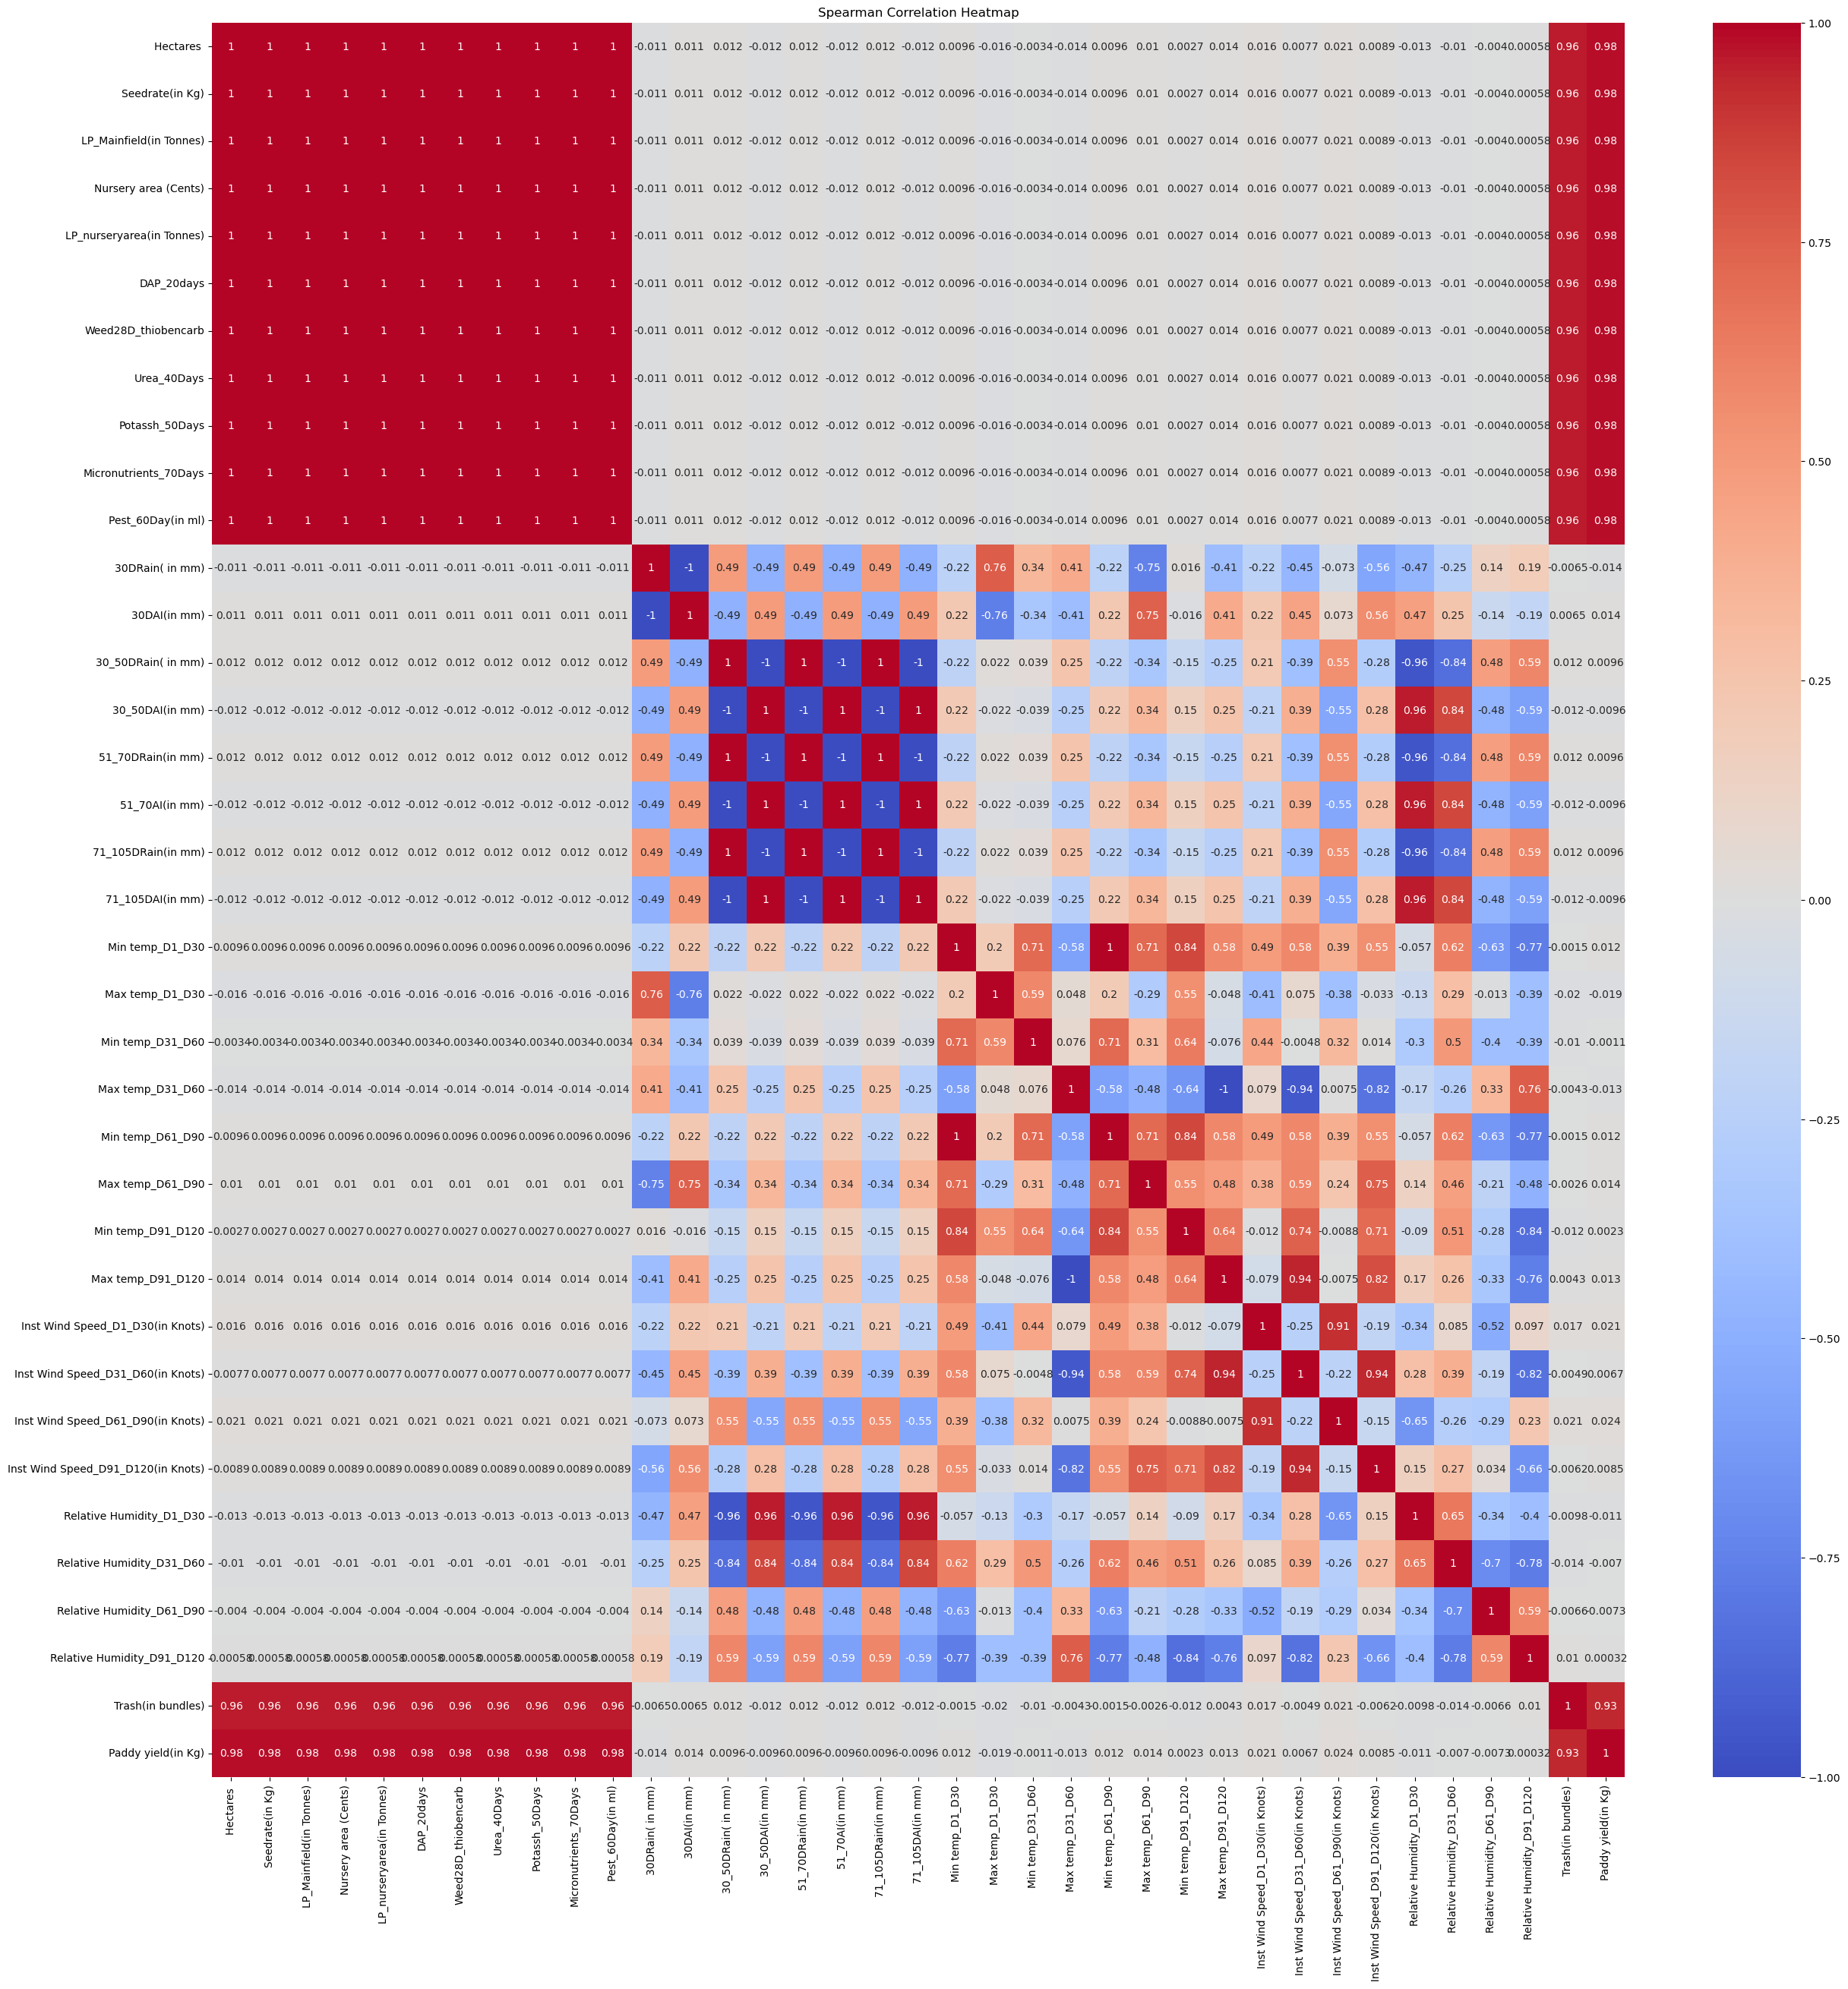

In [536]:
plt.figure(figsize=(30,30))
corr = df.corr(method='spearman', numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Spearman Correlation Heatmap")
plt.show()


There is a few correlation that showed the value of "1", upon further inspection of the dataset, it is found that those columns are human-controlled and are dependent variables. As for it's usage in this task, it will not be used as it's aimed to see enviromental effects or other effects have any impact on yield

In [537]:
cols_to_drop = [
    "Hectares ",
    "Seedrate(in Kg)",
    "LP_Mainfield(in Tonnes)",
    "Nursery area (Cents)",
    "LP_nurseryarea(in Tonnes)",
    "DAP_20days",
    "Weed28D_thiobencarb",
    "Urea_40Days",
    "Potassh_50Days",
    "Micronutrients_70Days",
    "Pest_60Day(in ml)"
]

df.drop(columns=cols_to_drop, inplace=True)

In [538]:
df["Total_Rainfall"] = (
    df["30DRain( in mm)"] +
    df["30_50DRain( in mm)"] +
    df["51_70DRain(in mm)"] +
    df["71_105DRain(in mm)"]
)
df["Avg_Temp"] = (
    df["Min temp_D1_D30"] + df["Max temp_D1_D30"] +
    df["Min temp_D31_D60"] + df["Max temp_D31_D60"] +
    df["Min temp_D61_D90"] + df["Max temp_D61_D90"] +
    df["Min temp_D91_D120"] + df["Max temp_D91_D120"]
) / 8
df["Avg_Humidity"] = (
    df["Relative Humidity_D1_D30"] +
    df["Relative Humidity_D31_D60"] +
    df["Relative Humidity_D61_D90"] +
    df["Relative Humidity_D91_D120"]
) / 4


In [539]:
df.info()

<class 'pandas.DataFrame'>
Index: 2338 entries, 0 to 2786
Data columns (total 37 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Agriblock                           2338 non-null   str    
 1   Variety                             2338 non-null   str    
 2   Soil Types                          2338 non-null   str    
 3   Nursery                             2338 non-null   str    
 4   30DRain( in mm)                     2338 non-null   float64
 5   30DAI(in mm)                        2338 non-null   float64
 6   30_50DRain( in mm)                  2338 non-null   float64
 7   30_50DAI(in mm)                     2338 non-null   float64
 8   51_70DRain(in mm)                   2338 non-null   float64
 9   51_70AI(in mm)                      2338 non-null   float64
 10  71_105DRain(in mm)                  2338 non-null   float64
 11  71_105DAI(in mm)                    2338 non-null   float64

In [540]:
df.describe()

,30DRain( in mm),30DAI(in mm),30_50DRain( in mm),30_50DAI(in mm),51_70DRain(in mm),51_70AI(in mm),71_105DRain(in mm),71_105DAI(in mm),Min temp_D1_D30,Max temp_D1_D30,...,Inst Wind Speed_D91_D120(in Knots),Relative Humidity_D1_D30,Relative Humidity_D31_D60,Relative Humidity_D61_D90,Relative Humidity_D91_D120,Trash(in bundles),Paddy yield(in Kg),Total_Rainfall,Avg_Temp,Avg_Humidity
count,2338.000000,2338.000000,2338.000000,2338.000000,2338.000000,2338.000000,2338.000000,2338.000000,2338.000000,2338.000000,...,2338.000000,2338.000000,2338.000000,2338.000000,2338.000000,2338.000000,2338.000000,2338.000000,2338.000000,2338.000000
mean,18.712789,21.287211,186.001540,271.998460,166.150513,250.849487,60.400770,64.599230,19.330838,33.114200,...,9.447391,76.384645,87.636441,85.180068,83.868691,337.408041,22610.117622,431.265612,24.893445,83.267462
std,0.640051,0.640051,0.851768,0.851768,0.676649,0.676649,0.425884,0.425884,0.873429,1.325906,...,2.516359,8.006073,6.781225,3.532307,3.149308,135.842185,9265.184949,2.498922,0.553745,2.594711
min,18.100000,20.400000,185.200000,270.800000,165.300000,250.000000,60.000000,64.000000,18.000000,31.000000,...,6.000000,64.600000,78.000000,81.000000,79.000000,80.000000,5410.000000,429.000000,24.125000,80.150000
25%,18.100000,20.400000,185.200000,270.800000,165.300000,250.000000,60.000000,64.000000,18.500000,32.000000,...,6.000000,72.000000,80.000000,83.000000,81.000000,240.000000,16359.000000,429.000000,24.250000,80.750000
50%,18.500000,21.500000,185.600000,272.400000,166.100000,250.900000,60.200000,64.800000,19.500000,33.000000,...,10.000000,72.700000,91.000000,84.000000,84.000000,360.000000,24644.000000,430.000000,25.187500,81.925000
75%,19.600000,21.900000,187.200000,272.800000,167.000000,251.700000,61.000000,65.000000,20.000000,34.000000,...,12.000000,85.000000,95.000000,88.000000,87.000000,450.000000,31035.000000,434.800000,25.375000,86.000000
max,19.600000,21.900000,187.200000,272.800000,167.000000,251.700000,61.000000,65.000000,20.500000,35.000000,...,12.000000,88.500000,96.000000,92.000000,88.000000,600.000000,38814.000000,434.800000,25.625000,87.125000


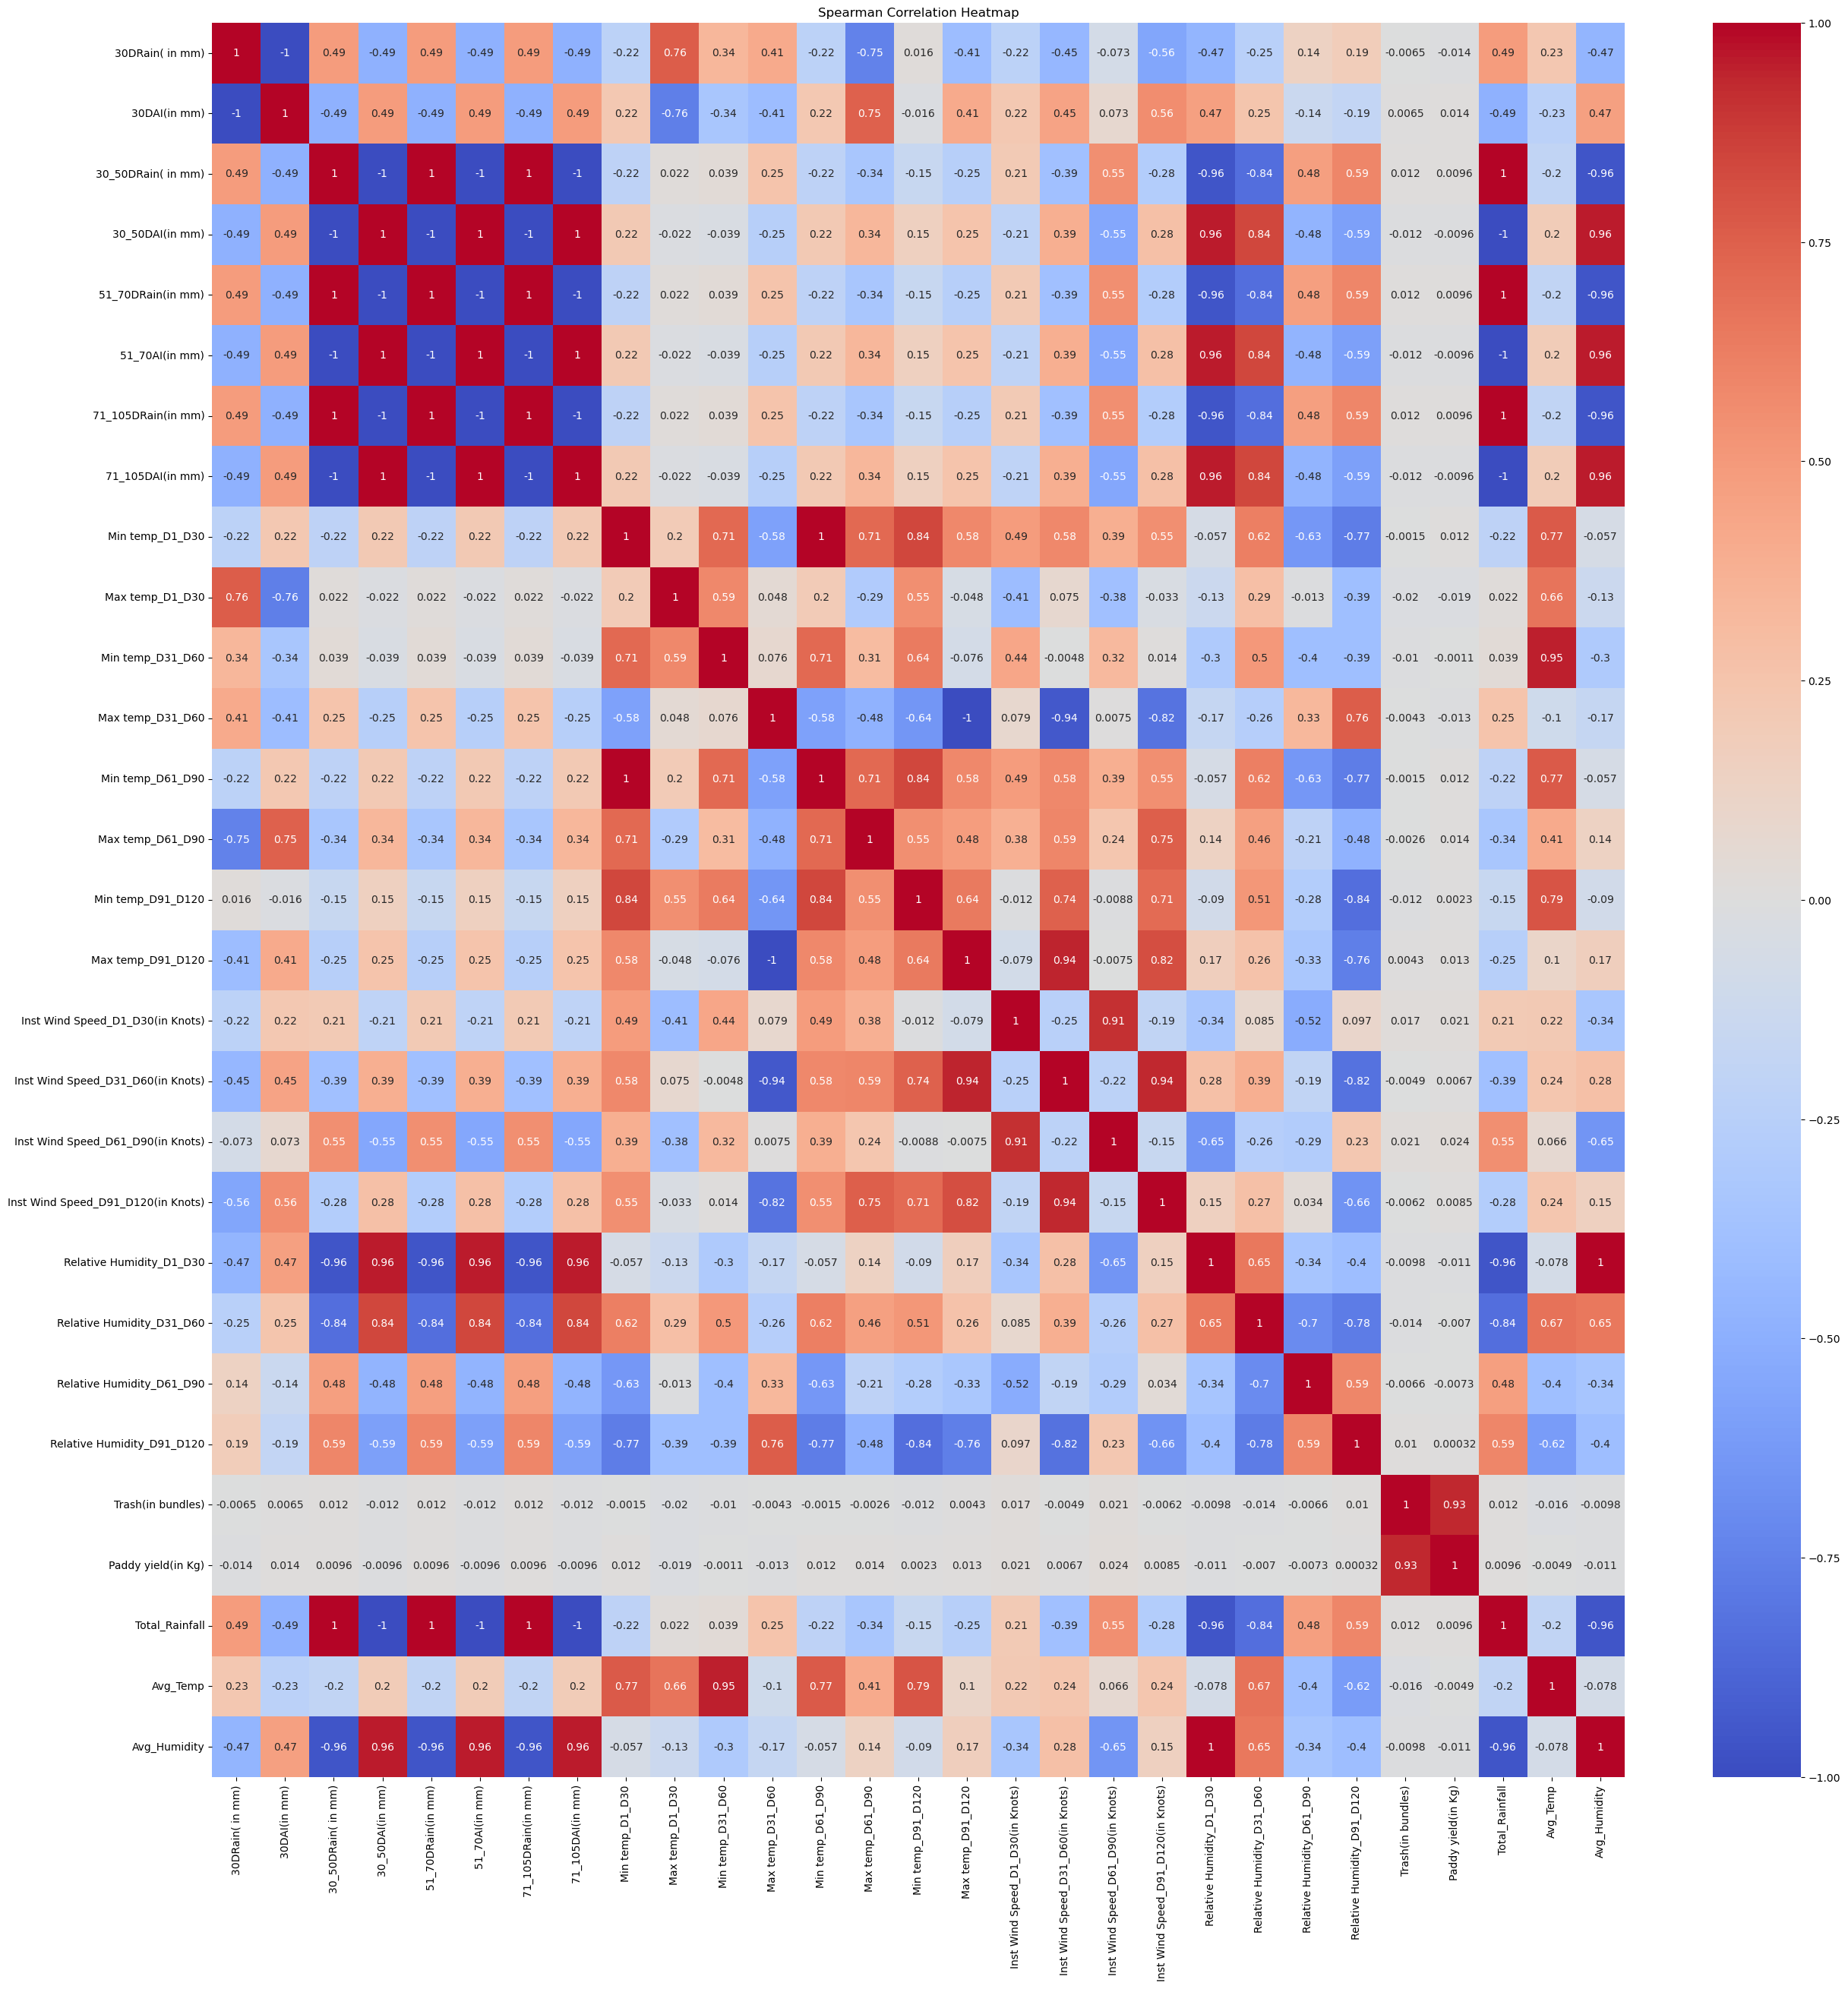

In [541]:
plt.figure(figsize=(30,30))
corr = df.corr(method='spearman', numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Spearman Correlation Heatmap")
plt.show()

## ====================== Descriptive Statistic =========================

In [542]:
stats = {}


for col in ["Total_Rainfall","Avg_Temp","Avg_Humidity", "Trash(in bundles)", "Paddy yield(in Kg)"]:
    stats[col] = {
        "mean": round(df[col].mean(),2),
        "median": df[col].median(),
        "mode": df[col].mode()[0],
        "std_dev": round(df[col].std(),2),
        "min": df[col].min(),
        "max": df[col].max(),
        "range": df[col].max() - df[col].min()
    }

print(pd.DataFrame(stats))


         Total_Rainfall  Avg_Temp  Avg_Humidity  Trash(in bundles)  \
mean             431.27   24.8900        83.270             337.41   
median           430.00   25.1875        81.925             360.00   
mode             430.00   25.1875        81.925             400.00   
std_dev            2.50    0.5500         2.590             135.84   
min              429.00   24.1250        80.150              80.00   
max              434.80   25.6250        87.125             600.00   
range              5.80    1.5000         6.975             520.00   

         Paddy yield(in Kg)  
mean               22610.12  
median             24644.00  
mode               17508.00  
std_dev             9265.18  
min                 5410.00  
max                38814.00  
range              33404.00  


In [543]:
df.groupby("Variety")["Paddy yield(in Kg)"].describe()


,count,mean,std,min,25%,50%,75%,max
Variety,,,,,,,,
CO_43,611.0,22482.001637,9394.471539,5410.0,16230.0,24644.0,31045.0,38814.0
delux ponni,832.0,22701.003606,9329.699781,5410.0,16359.0,24460.0,31035.0,38814.0
ponmani,895.0,22613.091620,9124.450701,5410.0,16389.0,24768.0,30885.0,38814.0


In [544]:
df.groupby("Soil Types")["Paddy yield(in Kg)"].describe()


,count,mean,std,min,25%,50%,75%,max
Soil Types,,,,,,,,
alluvial,1070.0,22576.675701,9286.448653,5410.0,16284.75,24644.0,31035.0,38814.0
clay,1268.0,22638.337539,9250.774799,5410.0,16361.25,24644.0,31035.0,38814.0


In [545]:
df.groupby("Agriblock")["Paddy yield(in Kg)"].describe()


,count,mean,std,min,25%,50%,75%,max
Agriblock,,,,,,,,
Chinnasalem,358.0,22565.659218,9459.773801,5410.0,16366.5,24776.0,31045.0,38508.0
Cuddalore,364.0,22611.489011,9094.464711,5410.0,16389.0,24644.0,30905.0,38814.0
Kallakurichi,353.0,22369.076487,9211.223502,5453.0,16260.0,24724.0,30905.0,38460.0
Kurinjipadi,401.0,22572.710723,9353.116237,5420.0,16389.0,24644.0,30905.0,38814.0
Panruti,360.0,22195.022222,9520.824875,5410.0,11861.0,24448.0,31045.0,38304.0
Sankarapuram,502.0,23137.884462,9048.797992,5453.0,16476.0,24644.0,31042.5,38814.0


In [546]:
df.groupby("Nursery")["Paddy yield(in Kg)"].describe()

,count,mean,std,min,25%,50%,75%,max
Nursery,,,,,,,,
dry,1255.0,22631.133068,9196.987958,5410.0,16476.0,24488.0,30952.5,38814.0
wet,1083.0,22585.764543,9347.785615,5410.0,11925.0,24724.0,31035.0,38814.0


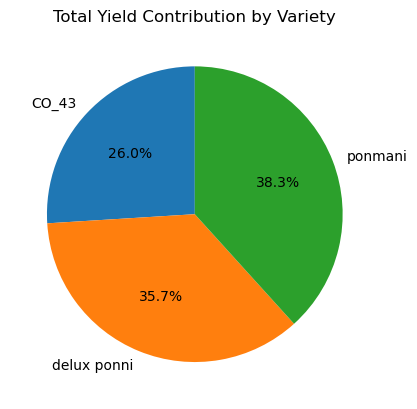

In [547]:
yield_by_variety = df.groupby("Variety")["Paddy yield(in Kg)"].sum()

plt.figure()

plt.pie(
    yield_by_variety,
    labels=yield_by_variety.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Total Yield Contribution by Variety")

plt.show()


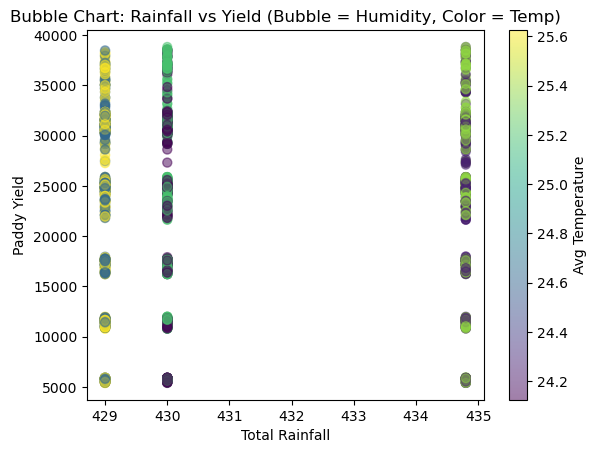

In [548]:
plt.figure()

# Bubble plot
plt.scatter(
    df["Total_Rainfall"], 
    df["Paddy yield(in Kg)"],
    s=df["Avg_Humidity"] * 0.5,   # bubble size (scaled)
    c=df["Avg_Temp"],             # color dimension
    alpha=0.5,
    cmap="viridis"
)

plt.colorbar(label="Avg Temperature")

plt.xlabel("Total Rainfall")
plt.ylabel("Paddy Yield")
plt.title("Bubble Chart: Rainfall vs Yield (Bubble = Humidity, Color = Temp)")

plt.show()

## ====================== Inferential Statistic ==============================

Normal Distribution or not 

H0 = Normal Distribution
H1 = Abnormal Distribution

In [549]:

from scipy.stats import shapiro

stat, p_value = shapiro(df["Paddy yield(in Kg)"])

print("Shapiro-Wilk Test")
print("p-value:", p_value)
print("Skewness:", df["Paddy yield(in Kg)"].skew())
print("Kurtosis:", df["Paddy yield(in Kg)"].kurt())


Shapiro-Wilk Test
p-value: 2.2716454699679644e-31
Skewness: -0.31686770437012085
Kurtosis: -1.0721826410563065


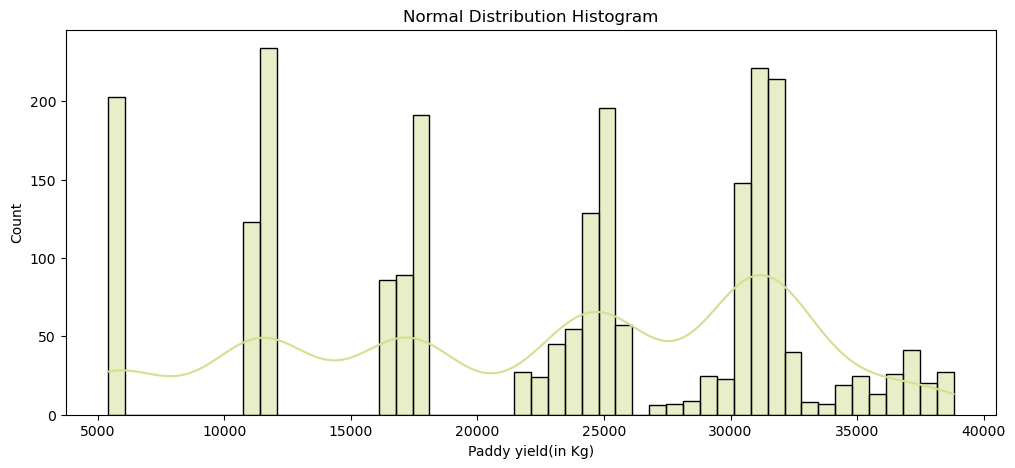

In [550]:
plt.figure(figsize=(12,5))
sns.histplot(data=df, x="Paddy yield(in Kg)", bins=50, kde=True, color="#d3df91")
plt.title("Normal Distribution Histogram")
plt.show()

Skewness value of -0.317 indicates that the distribution is relatively symmetric.

Kurtosis value of -1.072 indicates that the distribution is flatter than a normal distribution.

Shapiro–Wilk test result p value < 0.05

Conclusion:

The data is not normally distributed (Reject H₀).

Therefore, inferential analysis will be conducted using non-parametric methods.

In [551]:
from scipy.stats import spearmanr

target = "Paddy yield(in Kg)"
features = ["Total_Rainfall", "Avg_Temp", "Avg_Humidity", "Trash(in bundles)"]

for col in features:
    corr, p = spearmanr(df[col], df[target])
    
    print("\nRESULT:")
    print(f"Spearman Correlation: {corr}")
    print(f"p-value: {p}")

    if p < 0.05:
        print("Reject H0, There is evidence of a relationship.")
        
        if corr > 0:
            print("Positive relationship (as variable increases, yield tends to increase).")
        else:
            print("Negative relationship (as variable increases, yield tends to decrease).")
    
    else:
        print("Fail to Reject H0")
        print("Interpretation: There is NO significant evidence of a relationship.")
    
    print("="*40)
    


RESULT:
Spearman Correlation: 0.009646259312255188
p-value: 0.6410825617655005
Fail to Reject H0
Interpretation: There is NO significant evidence of a relationship.

RESULT:
Spearman Correlation: -0.004902764480725663
p-value: 0.8127053704818636
Fail to Reject H0
Interpretation: There is NO significant evidence of a relationship.

RESULT:
Spearman Correlation: -0.011435865996574366
p-value: 0.5804830301168136
Fail to Reject H0
Interpretation: There is NO significant evidence of a relationship.

RESULT:
Spearman Correlation: 0.9330908474904219
p-value: 0.0
Reject H0, There is evidence of a relationship.
Positive relationship (as variable increases, yield tends to increase).


TEST: Spearman Correlation — Total_Rainfall vs Yield

HYPOTHESIS:
H0: There is NO  relationship between Total_Rainfall and Paddy yield.
H1: There IS a relationship between Total_Rainfall and Paddy yield.

RESULT:
Spearman Correlation: 0.009646259312255188
p-value: 0.6410825617655005

RULE:
If p-value < 0.05 → Reject H0
If p-value ≥ 0.05 → Fail to reject H0

DECISION & INTERPRETATION:
Fail to Reject H0
Interpretation: There is NO significant evidence of a relationship.

===========================================================================

TEST: Spearman Correlation — Avg_Temp vs Yield

HYPOTHESIS:
H0: There is NO  relationship between Avg_Temp and Paddy yield.
H1: There IS a relationship between Avg_Temp and Paddy yield.

RESULT:
Spearman Correlation: -0.004902764480725663
p-value: 0.8127053704818636

RULE:
If p-value < 0.05 → Reject H0
If p-value ≥ 0.05 → Fail to reject H0

DECISION & INTERPRETATION:
Fail to Reject H0
Interpretation: There is NO significant evidence of a relationship.

===========================================================================


TEST: Spearman Correlation — Avg_Humidity vs Yield

HYPOTHESIS:
H0: There is NO  relationship between Avg_Humidity and Paddy yield.
H1: There IS a relationship between Avg_Humidity and Paddy yield.

RESULT:
Spearman Correlation: -0.011435865996574366
p-value: 0.5804830301168136

RULE:
If p-value < 0.05 → Reject H0
If p-value ≥ 0.05 → Fail to reject H0

DECISION & INTERPRETATION:
Fail to Reject H0
Interpretation: There is NO significant evidence of a relationship.

===========================================================================

TEST: Spearman Correlation — Trash(in bundles) vs Yield

HYPOTHESIS:
H0: There is NO  relationship between Trash(in bundles) and Paddy yield.
H1: There IS a relationship between Trash(in bundles) and Paddy yield.

RESULT:
Spearman Correlation: 0.9330908474904219
p-value: 0.0

RULE:
If p-value < 0.05 → Reject H0
If p-value ≥ 0.05 → Fail to reject H0

DECISION & INTERPRETATION:
Reject H0
Interpretation: There is evidence of a relationship.
Direction: Positive relationship (as variable increases, yield tends to increase).

===========================================================================


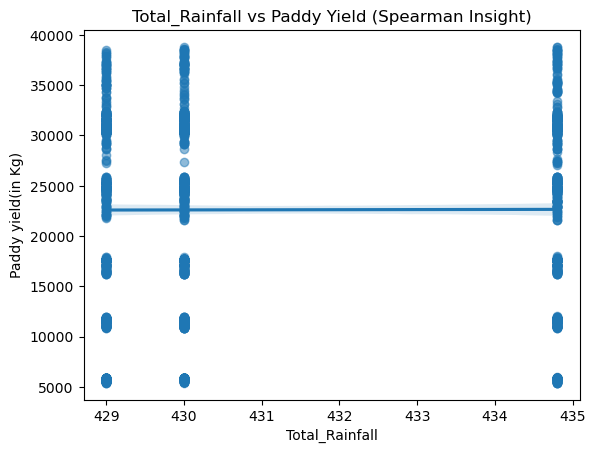

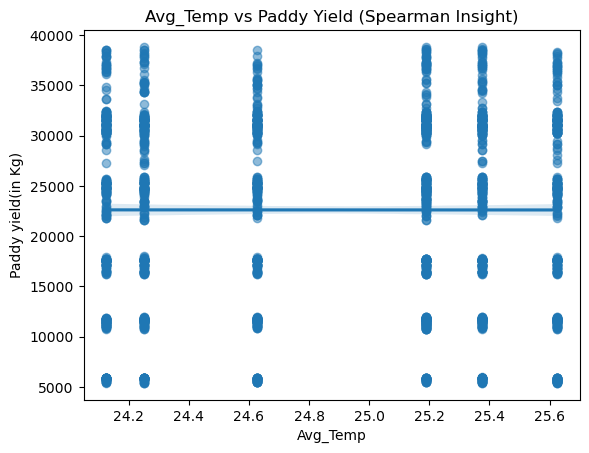

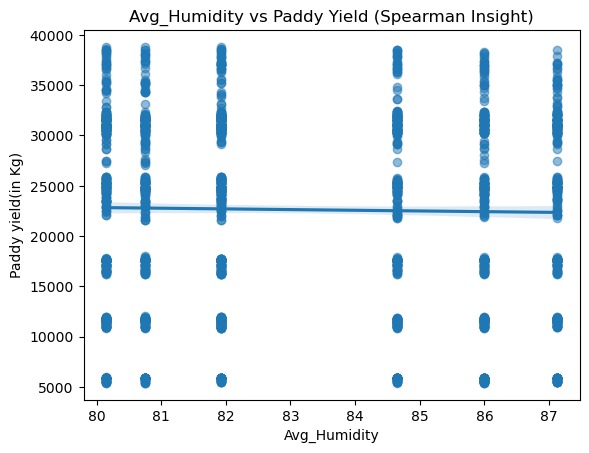

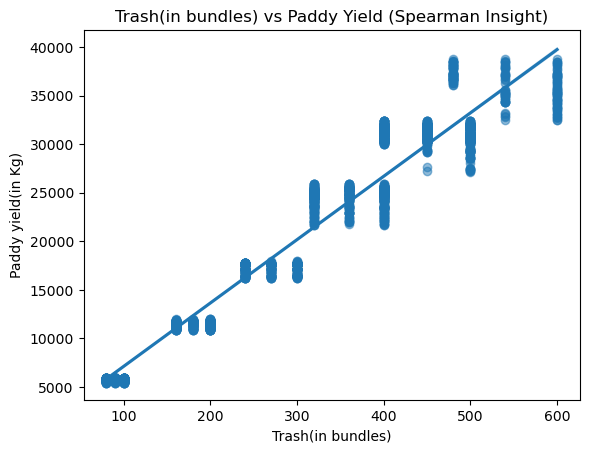

In [552]:
for col in features:
    plt.figure()
    sns.regplot(x=df[col], y=df[target], scatter_kws={'alpha':0.5})
    
    plt.title(f"{col} vs Paddy Yield (Spearman Insight)")
    plt.xlabel(col)
    plt.ylabel("Paddy yield(in Kg)")
    
    plt.show()


In [553]:
from scipy.stats import kruskal

categorical_cols = ["Variety", "Soil Types", "Agriblock", "Nursery"]
target = "Paddy yield(in Kg)"

for col in categorical_cols:
    groups = [group[target].values for name, group in df.groupby(col)]
    
    stat, p = kruskal(*groups)

    print(f"Kruskal-Wallis Statistic: {stat}")
    print(f"p-value: {p}")

    if p < 0.05:
        print("Reject H0")

    else:
        print("Fail to Reject H0")
    
    print("="*40)


Kruskal-Wallis Statistic: 0.022840466080772875
p-value: 0.9886447302870112
Fail to Reject H0
Kruskal-Wallis Statistic: 0.04193477953635509
p-value: 0.8377441449369383
Fail to Reject H0
Kruskal-Wallis Statistic: 2.006089394575785
p-value: 0.8483018119096488
Fail to Reject H0
Kruskal-Wallis Statistic: 0.005044665959836208
p-value: 0.9433772124175203
Fail to Reject H0


TEST: Kruskal-Wallis — Variety vs Yield

HYPOTHESIS:
H0: The median paddy yield is the SAME across all categories of Variety.
H1: At least ONE category of Variety has a DIFFERENT median paddy yield.

RESULT:
Kruskal-Wallis Statistic: 0.022840466080772875
p-value: 0.9886447302870112

DECISION RULE:
If p-value < 0.05 → Reject H0
If p-value ≥ 0.05 → Fail to reject H0

DECISION & INTERPRETATION:
Fail to Reject H0
Interpretation: There is NO statistically significant difference in median yield across groups of Variety.

This means Variety does NOT have a significant effect on paddy yield.


===========================================================================


TEST: Kruskal-Wallis — Soil Types vs Yield

HYPOTHESIS:
H0: The median paddy yield is the SAME across all categories of Soil Types.
H1: At least ONE category of Soil Types has a DIFFERENT median paddy yield.

RESULT:
Kruskal-Wallis Statistic: 0.04193477953635509
p-value: 0.8377441449369383

DECISION RULE:
If p-value < 0.05 → Reject H0
If p-value ≥ 0.05 → Fail to reject H0

DECISION & INTERPRETATION:
Fail to Reject H0
Interpretation: There is NO statistically significant difference in median yield across groups of Soil Types.

This means Soil Types does NOT have a significant effect on paddy yield.


===========================================================================



TEST: Kruskal-Wallis — Agriblock vs Yield

HYPOTHESIS:
H0: The median paddy yield is the SAME across all categories of Agriblock.
H1: At least ONE category of Agriblock has a DIFFERENT median paddy yield.

RESULT:
Kruskal-Wallis Statistic: 2.006089394575785
p-value: 0.8483018119096488

DECISION RULE:
If p-value < 0.05 → Reject H0
If p-value ≥ 0.05 → Fail to reject H0

DECISION & INTERPRETATION:
Fail to Reject H0
Interpretation: There is NO statistically significant difference in median yield across groups of Agriblock.

This means Agriblock does NOT have a significant effect on paddy yield.


===========================================================================



TEST: Kruskal-Wallis — Nursery vs Yield

HYPOTHESIS:
H0: The median paddy yield is the SAME across all categories of Nursery.
H1: At least ONE category of Nursery has a DIFFERENT median paddy yield.

RESULT:
Kruskal-Wallis Statistic: 0.005044665959836208
p-value: 0.9433772124175203

DECISION RULE:
If p-value < 0.05 → Reject H0
If p-value ≥ 0.05 → Fail to reject H0

DECISION & INTERPRETATION:
Fail to Reject H0
Interpretation: There is NO statistically significant difference in median yield across groups of Nursery.

This means Nursery does NOT have a significant effect on paddy yield.


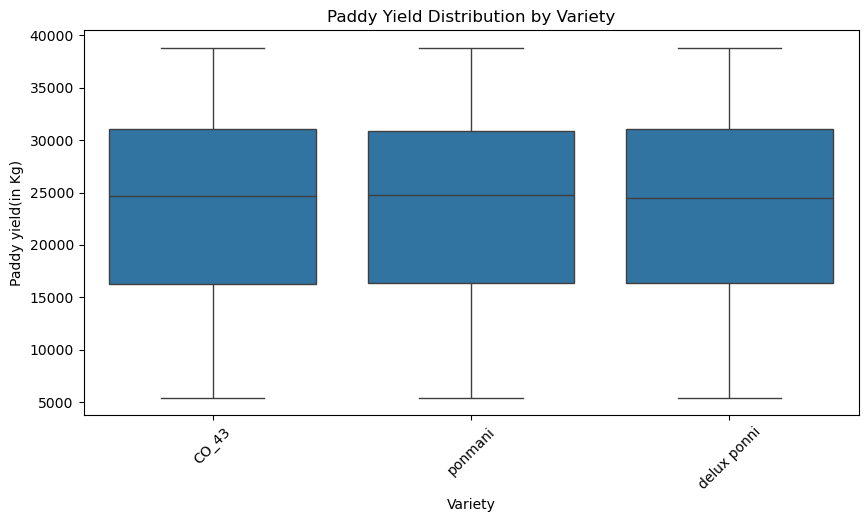

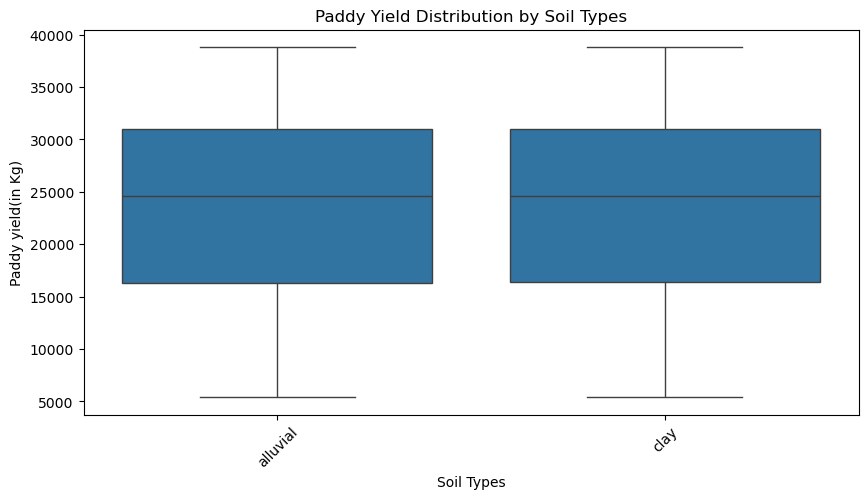

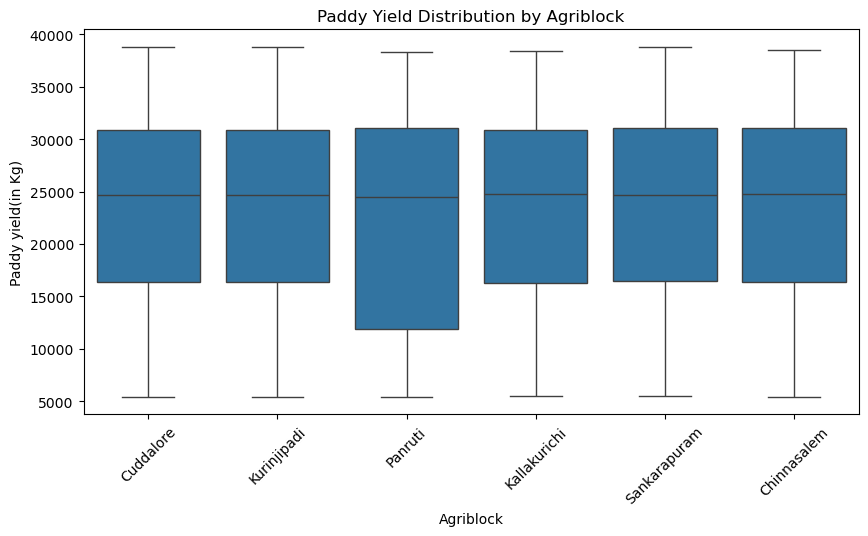

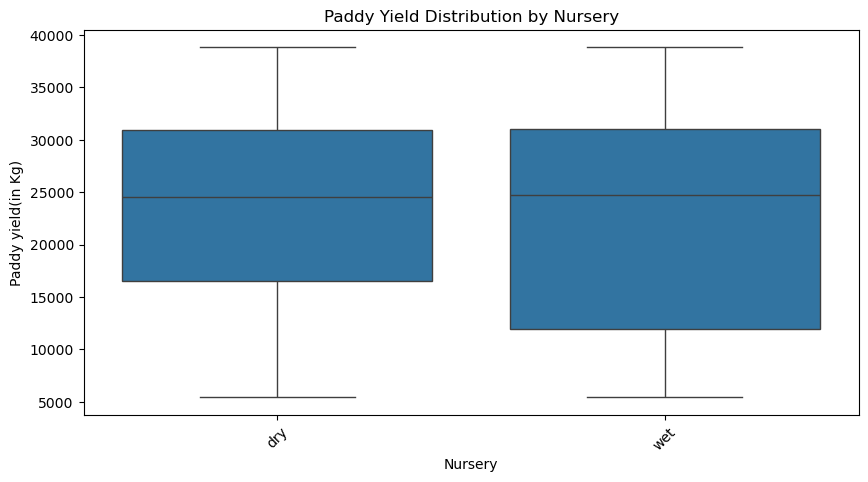

In [554]:
for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    
    sns.boxplot(x=df[col], y=df[target])
    
    plt.title(f"Paddy Yield Distribution by {col}")
    plt.xticks(rotation=45)
    
    plt.show()

## Conclusion

Although the skewness value (-0.317) indicates a relatively symmetric distribution and the kurtosis value (-1.072) suggests a flatter distribution, the Shapiro–Wilk test result (p < 0.05) confirms that the data significantly deviates from normality. Therefore, the null hypothesis of normality is rejected.

In response, non-parametric inferential methods were applied. The results consistently showed that aggregated environmental variables (total rainfall, average temperature, and average humidity) do not show significant relationships with paddy yield.

In contrast, earlier observations indicated that management-related variables (seedrate, pest, urea, and other controlled) have a very strong association with yield, suggesting that yield variation in this dataset is influenced by human-controlled rather than environmental condition